In [1]:
## Data Downloader
import urllib.request
import zipfile
from pathlib import Path

DATA_DIR = Path("data")

def download_file(url: str, destination: Path):
    """
    Download a file from a URL and save it to a destination path.
    """
    destination.parent.mkdir(parents=True, exist_ok=True)
    if not destination.exists():
        urllib.request.urlretrieve(url, destination)

def download_course_data():
    """
    Download the course data from mlip-cmu-online.
    """
    url: str = "https://github.com/mlip-cmu-online/public-data/raw/refs/heads/main/m0/data/"
    filenames: list[str] = [
        "events.csv.gz",
        "users.csv.gz",
        "movies.csv.gz"
    ]
    for filename in filenames:
        download_file(f"{url}/{filename}", DATA_DIR / filename)
    
def download_movielens_data():
    """
    Download movielens data for additional interaction data
    """
    url: str = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    zip_path: Path = DATA_DIR / "ml-latest-small.zip"
    ratings_path: Path = DATA_DIR / "ml-latest-small" / "ratings.csv"
    download_file(url, zip_path)
    if not ratings_path.exists():
        with zipfile.ZipFile(zip_path) as z:
            z.extractall(DATA_DIR)


download_course_data()
download_movielens_data()


In [2]:
# read course data
import pandas as pd

events = pd.read_csv(DATA_DIR / "events.csv.gz")
users = pd.read_csv(DATA_DIR / "users.csv.gz")
movies = pd.read_csv(DATA_DIR / "movies.csv.gz")

events.head()

,timestamp,user_id,event_type,movie_id,rating
0,2025-01-01T00:00:00,1,watch,jumanji+1995,NaN
1,2025-01-01T00:01:00,1,rating,jumanji+1995,7.0
2,2025-01-01T00:02:00,1,watch,the+city+of+lost+children+1995,NaN
3,2025-01-01T00:03:00,1,rating,the+city+of+lost+children+1995,7.0
4,2025-01-01T00:04:00,1,watch,twelve+monkeys+1995,NaN


<Axes: >

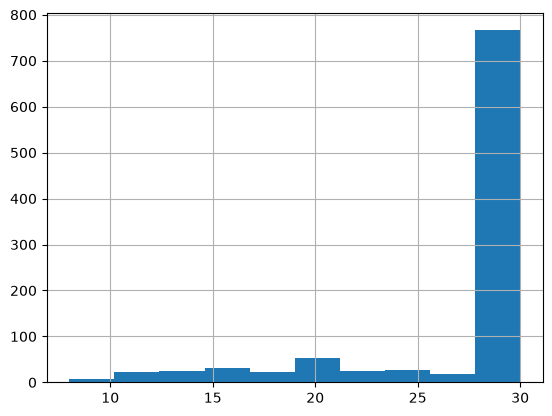

In [3]:
ratings = events[events["event_type"] == "rating"]

# distribution of ratings per user
ratings.groupby("user_id").size().hist()

<Axes: >

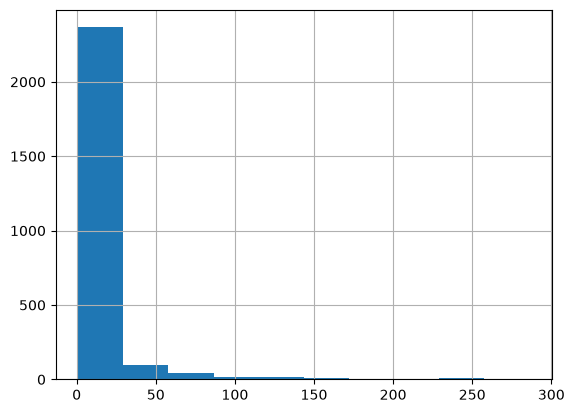

In [4]:
# distribution of ratings per movie
ratings.groupby("movie_id").size().hist()

<Axes: xlabel='rating'>

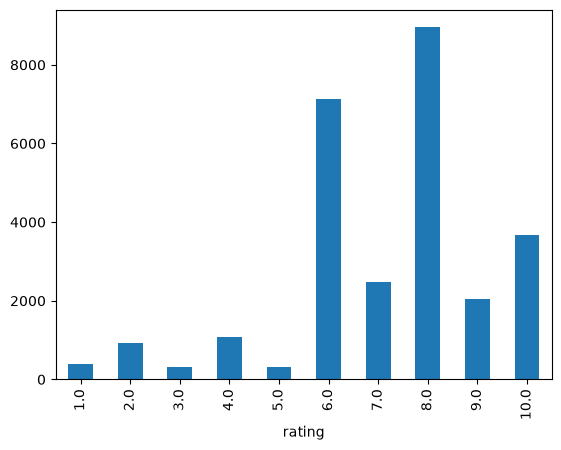

In [5]:
# distribution of rating value
ratings.groupby("rating").size().plot(kind="bar")

<Axes: >

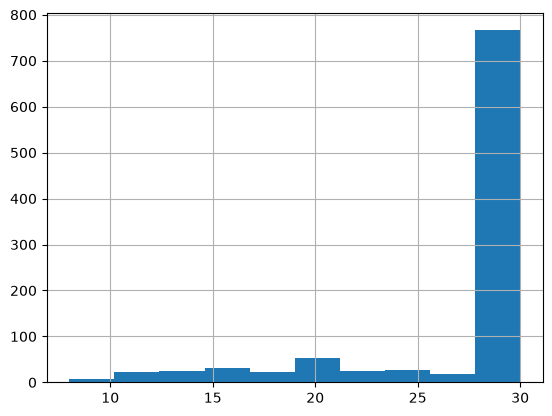

In [6]:
watchings = events[events["event_type"] == "watch"]

# distribution of watchings per user
watchings.groupby("user_id").size().hist()

<Axes: >

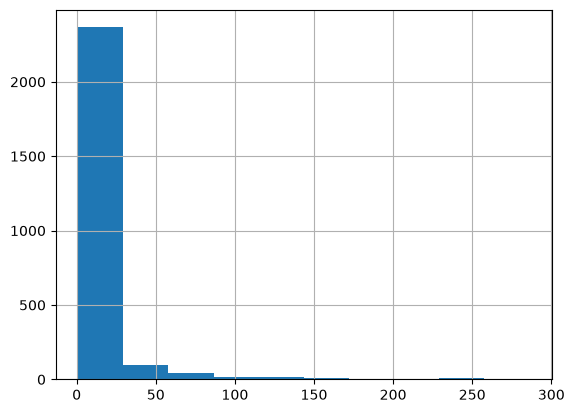

In [7]:
# distribution of watchings per movie
watchings.groupby("movie_id").size().hist()

In [8]:
movielens_ratings = pd.read_csv(DATA_DIR / 'ml-latest-small' / 'ratings.csv')
movielens_ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


<Axes: >

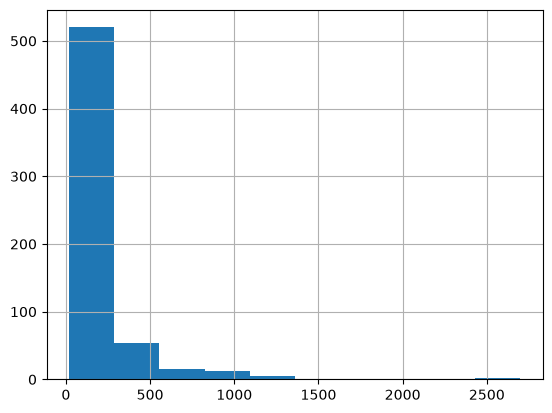

In [9]:
# distribution of ratings per user
movielens_ratings.groupby("userId").size().hist()

<Axes: >

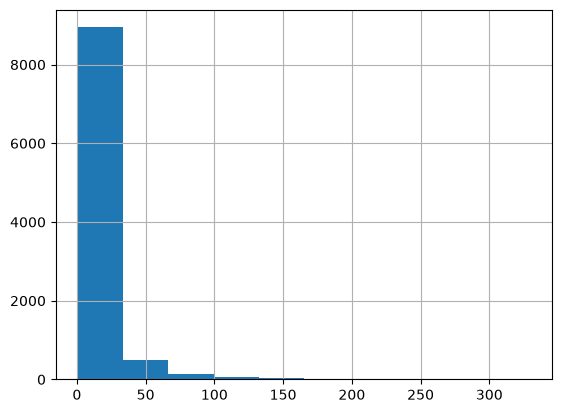

In [10]:
# distribution of ratings per movie
movielens_ratings.groupby("movieId").size().hist()

<Axes: xlabel='rating'>

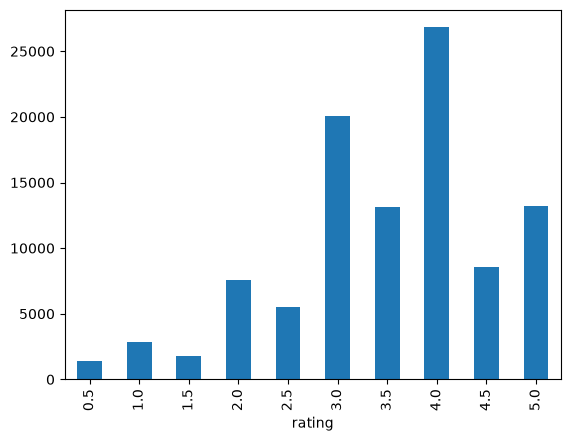

In [11]:
# distribution of ratings value
movielens_ratings.groupby("rating").size().plot(kind="bar")

In [12]:
movies.head()

,movie_id,title,genres,release_date,runtime,original_language,overview,popularity,vote_average,vote_count,imdb_id,tmdb_id,license_cost
0,...and+justice+for+all+1979,...And Justice for All,Drama,1979-10-19,119,en,An ethical Baltimore defense lawyer disgusted ...,2.4490,7.100,564,tt0078718,17443,0.076113
1,10+1979,10,Comedy|Romance,1979-10-05,122,en,A Hollywood songwriter goes through a mid-life...,7.8622,5.738,290,tt0078721,9051,0.096770
2,10+things+i+hate+about+you+1999,10 Things I Hate About You,Comedy|Romance|Drama,1999-03-30,97,en,"On the first day at his new school, Cameron in...",10.0086,7.590,8721,tt0147800,4951,0.138000
3,100+rifles+1969,100 Rifles,Adventure|Action|Western|War,1969-03-26,110,en,When half-breed Indian Yaqui Joe robs an Arizo...,4.1513,5.888,103,tt0063970,37308,0.008385
4,101+dalmatians+1996,101 Dalmatians,Family|Comedy,1996-11-27,103,en,"An evil, high-fashion designer plots to steal ...",5.0395,5.942,3565,tt0115433,11674,0.200000


In [13]:
users.head()

,user_id,age,occupation,gender,self_description_likes,self_description_dislikes
0,1,34,sales/marketing,M,NaN,NaN
1,2,33,college/grad student,M,"My liking is for action, adventure, crime genr...","I avoid horror movies, especially sequels. Als..."
2,3,29,scientist,M,"Crime, comedy, sci-fi, drama.","Bad sci-fi, cheesy romance."
3,4,30,other or not specified,M,NaN,NaN
4,5,26,scientist,M,"Stuff like Shawshank, Apollo 13, Star Wars. Ba...","Seriously, no Happy Gilmore or Willy Wonka. Ju..."


<Axes: >

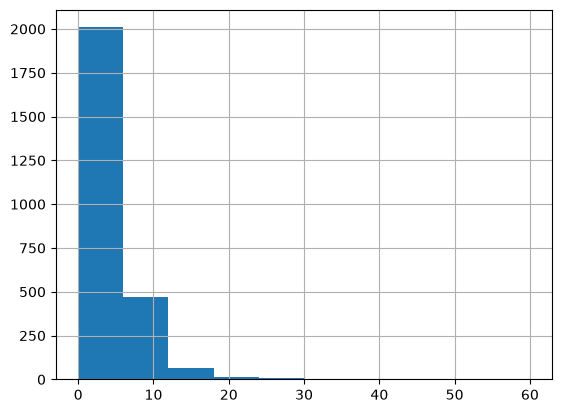

In [14]:
movies["popularity"].hist()

<Axes: >

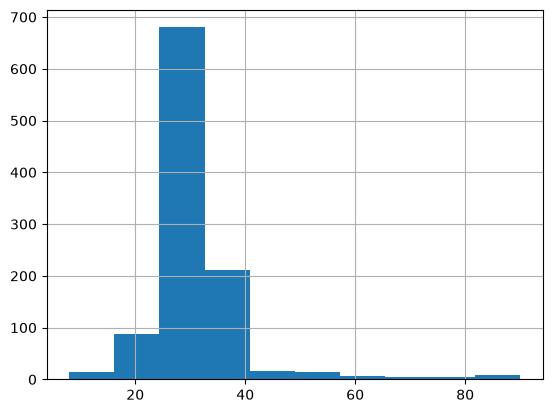

In [15]:
users["age"].hist()

<Axes: xlabel='genres'>

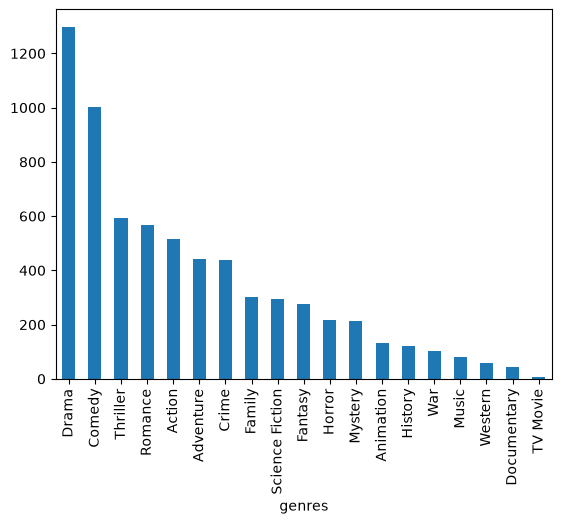

In [16]:
movies["genres"].str.split("|").explode().value_counts().plot(kind="bar")

<Axes: >

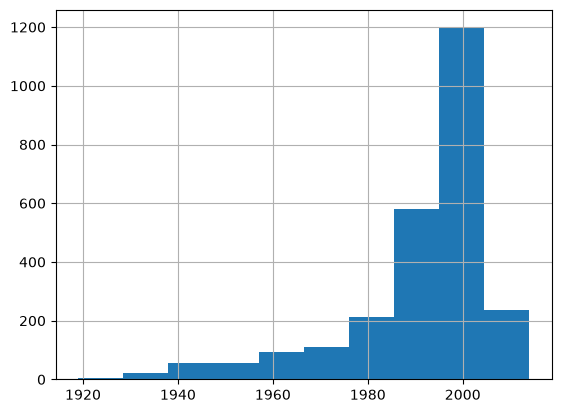

In [17]:
pd.to_datetime(movies["release_date"]).dt.year.hist()

In [18]:
users["self_description_likes"].isna().value_counts()

self_description_likes
False    753
True     297
Name: count, dtype: int64

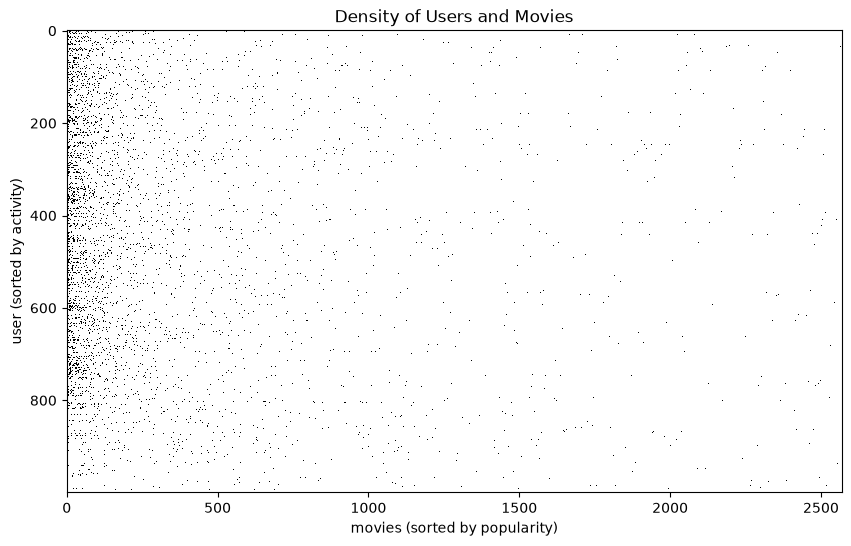

In [19]:
import matplotlib.pyplot as plt

matrix = ratings.pivot_table(index="user_id", columns="movie_id", values="rating")


def create_sorted_density_map(matrix, name: str | None, ylabel: str | None, xlabel: str | None):

    row_order = matrix.notna().sum(axis=1).sort_values(ascending=False).index
    col_order = matrix.notna().sum(axis=0).sort_values(ascending=False).index
    
    sorted_matrix = matrix.loc[row_order, col_order]
    
    plt.figure(figsize=(10, 6))
    plt.imshow(sorted_matrix.notna(), aspect="auto", cmap="Greys", interpolation="none")
    plt.xlabel(xlabel or "x")
    plt.ylabel(ylabel or "y")
    plt.title(name or "Density" )

create_sorted_density_map(matrix, "Density of Users and Movies", "user (sorted by activity)", "movies (sorted by popularity)")

In [20]:
# density of the course interaction matrix
course_density = matrix.notna().sum().sum() / (matrix.shape[0] * matrix.shape[1])
print(f"{course_density:.4%}")

1.0637%


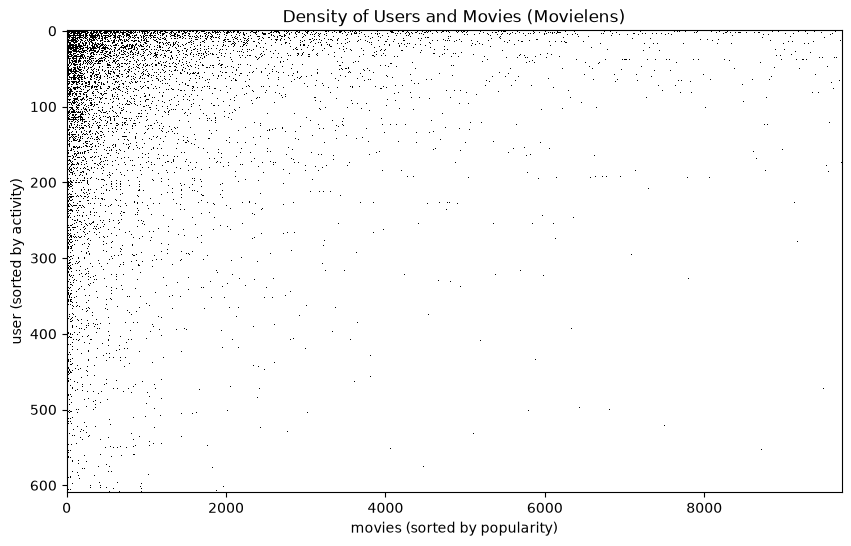

In [21]:
matrix2 = movielens_ratings.pivot_table(index="userId", columns="movieId", values="rating")

create_sorted_density_map(matrix2, "Density of Users and Movies (Movielens)", "user (sorted by activity)", "movies (sorted by popularity)")

In [29]:
# density of the movielens interaction matrix
movielens_density = matrix2.notna().sum().sum() / (matrix2.shape[0] * matrix2.shape[1])
print(f"{movielens_density:.4%}")

1.7000%


In [22]:
# use the links table to merge the movies together
movielens_links = pd.read_csv(DATA_DIR / 'ml-latest-small' / 'links.csv')
movielens_links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [ ]:
# merge course and movielens interactions on tmdb id
ratings_join_table = movies.merge(movielens_links, left_on="tmdb_id", right_on="tmdbId", how="inner")[["movie_id", "movieId"]]

movielens_ratings_mapped = movielens_ratings.merge(ratings_join_table, on="movieId", how="inner")[["userId", "movie_id", "rating"]]

# namespace the users (no user merge)
movielens_ratings_mapped["user_id"] = "movielens_" + movielens_ratings_mapped["userId"].astype(str)

coursedata_ratings_namespaced = ratings[["user_id", "movie_id", "rating"]].copy()
coursedata_ratings_namespaced["user_id"] = "course_" + coursedata_ratings_namespaced["user_id"].astype(str)

# normalize the ratings using z-score
course_rating_mean = coursedata_ratings_namespaced["rating"].mean()
course_rating_std = coursedata_ratings_namespaced["rating"].std()

coursedata_ratings_namespaced["rating_norm"] = (
    (coursedata_ratings_namespaced["rating"] - course_rating_mean) / course_rating_std
)

movielens_ratings_mean = movielens_ratings_mapped["rating"].mean()
movielens_ratings_std = movielens_ratings_mapped["rating"].std()

movielens_ratings_mapped["rating_norm"] = (
    (movielens_ratings_mapped["rating"] - movielens_ratings_mean) / movielens_ratings_std
)

# combine into one long table
ratings_combined = pd.concat([
    coursedata_ratings_namespaced[["user_id", "movie_id", "rating_norm"]],
    movielens_ratings_mapped[["user_id", "movie_id", "rating_norm"]],
])
# pivot
ratings_matrix = ratings_combined.pivot_table(index="user_id", columns="movie_id", values="rating_norm")

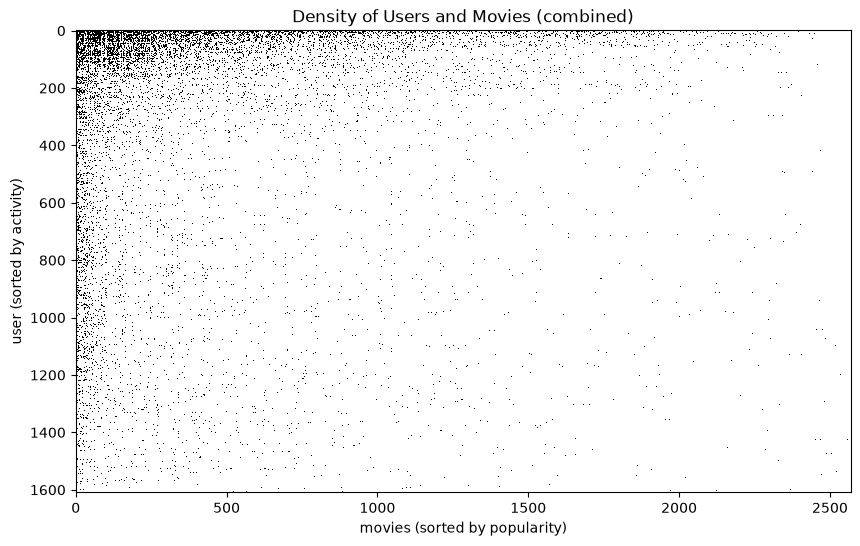

In [ ]:
create_sorted_density_map(ratings_matrix, "Density of Users and Movies (combined)", "user (sorted by activity)", "movies (sorted by popularity)")

In [ ]:
# density of the combined interaction matrix
combined_density = ratings_matrix.notna().sum().sum() / (matrix2.shape[0] * matrix2.shape[1])
print(f"{combined_density:.4%}")

1.6854%


In [ ]:
# let's try collaborative filtering
from sklearn.metrics.pairwise import cosine_similarity

ratings_filled = ratings_matrix.fillna(0)
item_similarity = cosine_similarity(ratings_filled.T)
item_similarity_dataframe = pd.DataFrame(item_similarity, index=ratings_filled.columns, columns=ratings_filled.columns)

In [ ]:
def predict_rating(user_id, movie_id, neighborhood_size=10):
    user_ratings = ratings_matrix.loc[user_id].dropna()
    candidates = item_similarity_dataframe.loc[movie_id, user_ratings.index]
    candidates = candidates[candidates > 0]
    neighborhood = candidates.sort_values(ascending=False).head(neighborhood_size)
    if neighborhood.sum() == 0:
        return None
    return (neighborhood * user_ratings[neighborhood.index]).sum() / neighborhood.sum()

predict_rating('course_1', 'jumanji+1995')

np.float64(-0.09814425201970164)

In [26]:
# convert the rating back to the original scale for readibility

def convert_ratings_to_course_scale(zscore):
    return zscore * course_rating_std + course_rating_mean

convert_ratings_to_course_scale(predict_rating('course_1', 'jumanji+1995'))

np.float64(6.9766338473609295)

In [ ]:
def recommend(user_id, n=5):
    unrated = ratings_matrix.loc[user_id][ratings_matrix.loc[user_id].isna()].index
    candidates = {m: predict_rating(user_id, m) for m in unrated}
    candidates = {m: p for m, p in candidates.items() if p is not None}
    top_candidates = pd.Series(candidates).sort_values(ascending=False).head(n)
    return top_candidates.apply(convert_ratings_to_course_scale)

recommend('course_1')

cosi+1996                         8.0
in+the+shadow+of+the+moon+2007    8.0
resurrection+1980                 8.0
the+independent+2000              8.0
ossessione+1943                   8.0
dtype: float64

In [28]:
# The interaction data is really sparse outside the most popular movies.
# TODO - a hybrid approach that uses item-item interaction similarity and attribute similarity

In [44]:
# cold start plan: compare new user free text to warm user free text (embedding model) 
# put new user in neighborhood of warm users and seed their interaction history
# we should do genre and movie extraction too - not sure how to work that in yet.

# Let's make some LLM calls
from dotenv import load_dotenv
from google import genai
from google.genai.errors import ClientError

In [39]:
load_dotenv()
client = genai.Client() 

# test generation
response = client.interactions.create(
    model="gemini-3.8-flash",
    input="Say hello in one sentence."
)
print(response.output_text)

# test embeddings
embedding_response = client.models.embed_content(
    model="gemini-embedding-001",
    contents="I like long walks on the beach."
)
print(embedding_response)

Hello, I hope you are having a wonderful day!
sdk_http_response=HttpResponse(
  headers=<dict len=11>
) embeddings=[ContentEmbedding(
  values=[
    -0.01784788,
    0.0033752555,
    -0.018514857,
    -0.09045044,
    -0.0005802794,
    <... 3067 more items ...>,
  ]
)] metadata=None


In [40]:
# let's make the embeddings of warm users' free text
# filter to users with ratings history
warm_user_ids = set(ratings["user_id"].unique())
warm_users = users[users["user_id"].isin(warm_user_ids)].copy()

warm_users["description_text"] = (
    warm_users["self_description_likes"].fillna("") + " " +
    warm_users["self_description_dislikes"].fillna("")
).str.strip()

warm_users = warm_users[warm_users["description_text"] != ""]


In [49]:
import time

def embed_text(text: str) -> list[float]:
    response = client.models.embed_content(
        model="gemini-embedding-001",
        contents=text,
    )
    return response.embeddings[0].values

def load_warm_embeddings():
    # if this ran already, you should have the vectors saved locally
    warm_embeddings_path = DATA_DIR / "warm_embeddings.csv"
    all_ids = "course_" + warm_users["user_id"].astype(str)

    if warm_embeddings_path.exists():
        existing = pd.read_csv(warm_embeddings_path, index_col=0)
    else:
        existing = pd.DataFrame()
    # saves happen after each batch (rate limiting problems) 
    # check for remaining IDs; getting the embeddings from the LLM is idempotent
    remaining = warm_users[~all_ids.isin(existing.index).values]

    if len(remaining) == 0:
        print('Embeddings loaded from disk. 0 missing user IDs.')
        return existing

    print(f"Missing  {len(remaining)}/{len(all_ids)} users. Getting content embeddings now....")
    texts = remaining["description_text"].tolist()
    ids = "course_" + remaining["user_id"].astype(str)
    total = len(texts)
    batch_size = 50

    for i in range(0, total, batch_size):
        batch_texts = texts[i:i + batch_size]
        batch_ids = ids.iloc[i:i + batch_size]

        while True:
            try:
                response = client.models.embed_content(
                    model="gemini-embedding-001",
                    contents=batch_texts,
                )
                break
            except ClientError as e:
                if e.code == 429:
                    print("Rate limited, waiting 60s...")
                    time.sleep(60)
                else:
                    raise

        # save batch to file
        batch_embeddings = [e.values for e in response.embeddings]
        batch_df = pd.DataFrame(batch_embeddings, index=batch_ids)
        batch_df.to_csv(warm_embeddings_path, mode="a", header=not warm_embeddings_path.exists())

        print(f"Embedded {min(i + batch_size, total)}/{total} remaining (saved)")
        time.sleep(2)

    return pd.read_csv(warm_embeddings_path, index_col=0)


warm_embeddings = load_warm_embeddings()

Embeddings loaded from disk. 0 missing user IDs.


In [ ]:
def find_similar_users(cold_user_text, k=5):
    cold_embedding = embed_text(cold_user_text)
    similarity_table = cosine_similarity([cold_embedding], warm_embeddings.values)[0]
    neighbors = pd.Series(similarity_table, index=warm_embeddings.index)
    return neighbors.sort_values(ascending=False).head(k)


# chose your adventure
# I wonder if this will match with romance and family movies, no genres or movies named.
my_neighborhood = find_similar_users("I like long walks on the beach and sitting by the fireplace. I don't like conflict.")
# Let's see how this is different
# my_neighborhood = find_similar_users("I like car chases and explosions. No sappy movies.")
# Named some genres and movies
# my_neighborhood = find_similar_users("I like Titanic and The Notebook. I don't like horror movies.")

print("Similarity scores:")
print(my_neighborhood)
print()
print(my_neighborhood.describe())
print()

# who are these people
neighbor_ids_raw = my_neighborhood.index.str.replace("course_", "", regex=False).astype(int)
neighbor_descriptions = warm_users[warm_users["user_id"].isin(neighbor_ids_raw)][["user_id", "description_text"]]
print(neighbor_descriptions)
print()

# how much actual rating signal per neighbor
neighbor_rating_counts = ratings_matrix.loc[my_neighborhood.index].notna().sum(axis=1)
print("Ratings per neighbor:")
print(neighbor_rating_counts)

Similarity scores:
user_id
course_591    0.682917
course_885    0.680844
course_41     0.672287
course_936    0.670063
course_702    0.669631
dtype: float64

count    5.000000
mean     0.675148
std      0.006270
min      0.669631
25%      0.670063
50%      0.672287
75%      0.680844
max      0.682917
dtype: float64

     user_id                                   description_text
40        41  I like famly movis, fantacy, adventure. Classi...
590      591  What I like: Family movie, animation. Like Toy...
701      702  My preference is for dramatic and thriller mov...
884      885  What I like: Popular movies. History, Crime, R...
935      936  I like movies, drama, thriller, comedy. Like L...

Ratings per neighbor:
user_id
course_591    30
course_885    30
course_41     30
course_936    30
course_702    30
dtype: int64
